# 第九次课后练习


<span style="color:red; font-weight:bold;">请将作业文件命名为 第九次课后练习+姓名+学号.ipynb, 例如 第九次课后练习+张三+1000000000.ipynb</span>

<span style="color:red; font-weight:bold;">在作业过程中觉得有心得或者自己拓展学习到有价值内容的，可以在文件名最后加一个#号。例如第十次课后练习+张三+1000000000+#.ipynb</span>


# 第零部分 代码理解

请认真阅读代码，理解代码的功能，先写出预想的结果。运行并检验结果是否如预期。如果不如预期，请分析理解其中的原因

第零部分要全面，主要目的是带动同学们学习这些方法

第一部分则是对相关内容重点的一个考察

第二部分出一道全面综合的题目 或者 两道
    想出一道分词然后词频统计然后画图的题

选做题
    选做题想弄一道机器学习的题，手写朴素贝叶斯算法

## **0.1** groupby()函数
    阅读下面代码，观察运行的结果，解释出现这个结果的原因。

In [1]:
import pandas as pd
raw_data = {'regiment': ['Nighthawks', 'Nighthawks', 'Nighthawks', 'Nighthawks', 'Dragoons', 'Dragoons', 'Dragoons', 'Dragoons', 'Scouts', 'Scouts', 'Scouts', 'Scouts'], 
        'company': ['1st', '1st', '2nd', '2nd', '1st', '1st', '2nd', '2nd','1st', '1st', '2nd', '2nd'], 
        'name': ['Miller', 'Jacobson', 'Ali', 'Milner', 'Cooze', 'Jacon', 'Ryaner', 'Sone', 'Sloan', 'Piger', 'Riani', 'Ali'], 
        'preTestScore': [4, 24, 31, 2, 3, 4, 24, 31, 2, 3, 2, 3],
        'postTestScore': [25, 94, 57, 62, 70, 25, 94, 57, 62, 70, 62, 70]}
regiment = pd.DataFrame(raw_data, columns = raw_data.keys())
regiment

,regiment,company,name,preTestScore,postTestScore
0,Nighthawks,1st,Miller,4,25
1,Nighthawks,1st,Jacobson,24,94
2,Nighthawks,2nd,Ali,31,57
3,Nighthawks,2nd,Milner,2,62
4,Dragoons,1st,Cooze,3,70
5,Dragoons,1st,Jacon,4,25
6,Dragoons,2nd,Ryaner,24,94
7,Dragoons,2nd,Sone,31,57
8,Scouts,1st,Sloan,2,62
9,Scouts,1st,Piger,3,70


In [2]:
print("1.每个军团的平均测试前成绩是多少")
display(regiment.groupby('regiment')['preTestScore'].mean())

print("2.呈现每个company的统计数据")
display(regiment.groupby('company')[['preTestScore','postTestScore']].describe())

print("3.每个company的平均测试前成绩")
display(regiment.groupby('company')['preTestScore'].mean())

print("4.每个regiment和company的平均测试前成绩")
display(regiment.groupby(['regiment','company'])['preTestScore'].mean())

print("5.每个company下的regiment有多少条数据")
display(regiment.groupby(['company','regiment']).agg({'name':'count','preTestScore':'sum'}))

1.每个军团的平均测试前成绩是多少


regiment
Dragoons      15.50
Nighthawks    15.25
Scouts         2.50
Name: preTestScore, dtype: float64

2.呈现每个company的统计数据


preTestScore                                                      \
               count       mean        std  min   25%   50%    75%   max   
company                                                                    
1st              6.0   6.666667   8.524475  2.0  3.00   3.5   4.00  24.0   
2nd              6.0  15.500000  14.652645  2.0  2.25  13.5  29.25  31.0   

        postTestScore                                                       
                count       mean        std   min    25%   50%   75%   max  
company                                                                     
1st               6.0  57.666667  27.485754  25.0  34.25  66.0  70.0  94.0  
2nd               6.0  67.000000  14.057027  57.0  58.25  62.0  68.0  94.0

3.每个company的平均测试前成绩


company
1st     6.666667
2nd    15.500000
Name: preTestScore, dtype: float64

4.每个regiment和company的平均测试前成绩


regiment    company
Dragoons    1st         3.5
            2nd        27.5
Nighthawks  1st        14.0
            2nd        16.5
Scouts      1st         2.5
            2nd         2.5
Name: preTestScore, dtype: float64

5.每个company下的regiment有多少条数据


name  preTestScore
company regiment                      
1st     Dragoons       2             7
        Nighthawks     2            28
        Scouts         2             5
2nd     Dragoons       2            55
        Nighthawks     2            33
        Scouts         2             5

## **0.2** agg() 聚合函数
    阅读下面代码，观察运行的结果，解释出现这个结果的原因。

In [3]:
import pandas as pd
import numpy as np
# 构建数据
df = pd.DataFrame({
    '商品名称': ['药品A', '药品B', '药品C', '药品A', '药品B', '药品C'],
    '社保卡号': ['123', '123', '456', '456', '789', '789'],
    '购药时间': ['2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01'],
    '销售数量': [10, 20, 30, 40, 50, 60],
    '实收金额': [100, 200, 300, 400, 500, 600]
})

#查看数据类型
print(df)

#求不同药品的销售总量，最高销售数量
#对某一列进行多种聚合操作
print(df.groupby("商品名称")["销售数量"].agg([np.sum, np.max]))
print(df.groupby("商品名称")["销售数量"].agg(["sum", "max"]))

#求不同社保卡号的拿药次数和消费总金额
print(df.groupby("社保卡号").agg({"社保卡号": "count", "实收金额": "sum"}))

#求1季度不同药品的总销售金额和总销售数量
df["购药时间"]=pd.to_datetime(df["购药时间"])

#日期类型的数据如果作为索引，不需要加dt，如果日期类型是一列，需要加dt访问日期对象
df[df["购药时间"].dt.quarter==1].groupby("商品名称").agg({"实收金额":"sum","销售数量":"sum"})

#求每个月份，不同商品的销售总数量和平均销售额
m=df["购药时间"].dt.month
print(df.groupby([m,"商品名称"]).agg({"实收金额": "mean", "销售数量": "sum"}))

#统计每月，每种药品的最低和最高销售数量，平均和实收总金额
print(df.groupby([m, "商品名称"]).agg({"实收金额": ["mean", "sum"], "销售数量": ["max", "min"]}))

#统计每月  销售金额的跨度（每月实收金额最大值-每月最小值）
#1-7月  分为7个小组，a是每个小组的实收金额的数据
print(df.groupby(m)["实收金额"].agg(lambda a: a.max() - a.min()))

  商品名称 社保卡号        购药时间  销售数量  实收金额
0  药品A  123  2023-01-01    10   100
1  药品B  123  2023-02-01    20   200
2  药品C  456  2023-03-01    30   300
3  药品A  456  2023-04-01    40   400
4  药品B  789  2023-05-01    50   500
5  药品C  789  2023-06-01    60   600
      sum  max
商品名称          
药品A    50   40
药品B    70   50
药品C    90   60
      sum  max
商品名称          
药品A    50   40
药品B    70   50
药品C    90   60
      社保卡号  实收金额
社保卡号            
123      2   300
456      2   700
789      2  1100
            实收金额  销售数量
购药时间 商品名称             
1    药品A   100.0    10
2    药品B   200.0    20
3    药品C   300.0    30
4    药品A   400.0    40
5    药品B   500.0    50
6    药品C   600.0    60
            实收金额      销售数量    
            mean  sum  max min
购药时间 商品名称                     
1    药品A   100.0  100   10  10
2    药品B   200.0  200   20  20
3    药品C   300.0  300   30  30
4    药品A   400.0  400   40  40
5    药品B   500.0  500   50  50
6    药品C   600.0  600   60  60
购药时间
1    0
2    0
3    0
4    0
5    0
6    0
Nam

C:\Users\32698\AppData\Local\Temp\ipykernel_42608\458507451.py:17: FutureWarning: The provided callable <function sum at 0x000002B31C812480> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  print(df.groupby("商品名称")["销售数量"].agg([np.sum, np.max]))
C:\Users\32698\AppData\Local\Temp\ipykernel_42608\458507451.py:17: FutureWarning: The provided callable <function max at 0x000002B31C812E80> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  print(df.groupby("商品名称")["销售数量"].agg([np.sum, np.max]))


agg()的意思是实施函数，也就是对这一列实施这个两个或几个函数

## **0.3** 数据可视化
    阅读下面代码，观察运行的结果，解释出现这个结果的原因。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 创建一个 DataFrame
df = pd.DataFrame({
    'x': np.arange(1, 11),
    'y': np.random.randn(10)
})
df

,x,y
0,1,0.436855
1,2,1.263322
2,3,-0.329804
3,4,0.833130
4,5,-0.684740
5,6,-0.184749
6,7,-1.484280
7,8,-1.632102
8,9,-0.336334
9,10,0.097515


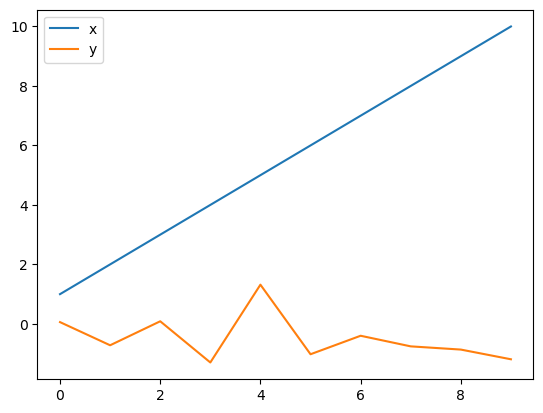

In [5]:
# 使用 plot() 函数绘制线图
df.plot(kind='line')
plt.show()

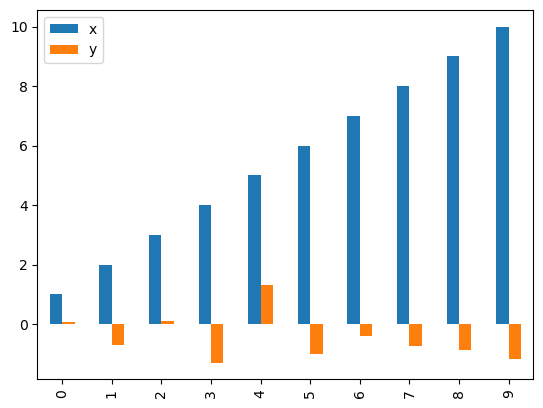

In [6]:
# 使用 plot() 函数绘制柱状图
df.plot(kind='bar')
plt.show()

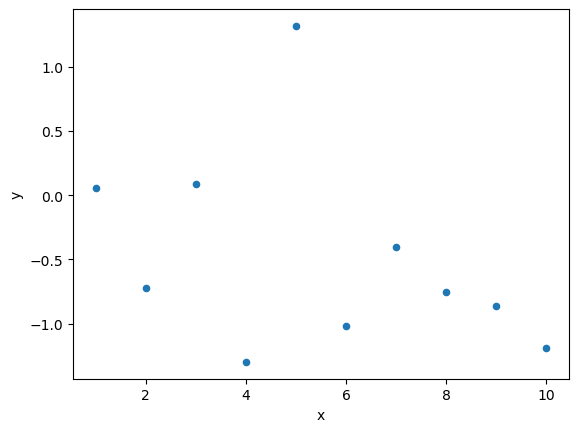

In [7]:
# 使用 plot() 函数绘制散点图
df.plot(kind='scatter', x='x', y='y')
plt.show()

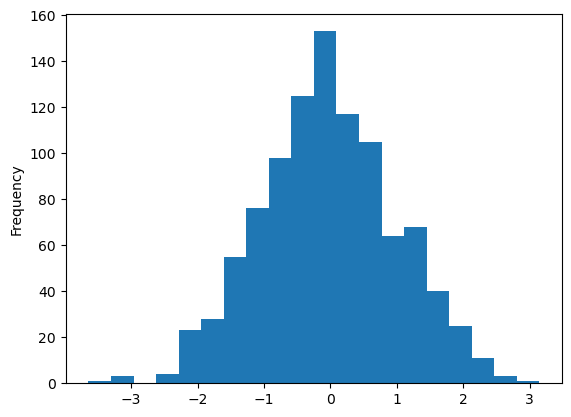

In [8]:
# 创建一个 DataFrame
df = pd.DataFrame({
    'x': np.random.randn(1000),
})

# 使用 plot() 函数绘制直方图
df['x'].plot(kind='hist', bins=20)

plt.show()

# 第一部分 基础练习

In [2]:
# 答案读取
import pandas as pd
import pickle

with open('stdout.pkl', 'rb') as f:
    stdout = pickle.load(f)

## **1.1** groupby()
    给定DataFrame，求A列每个值的前3大的B的和

In [13]:
df = pd.DataFrame({'A': list('aaabbcaabcccbbc'), 
                   'B': [12,345,3,1,45,14,4,52,54,23,235,21,57,3,87]})

##############################
# TODO 使用一行代码实现，求出每个组的前3个最大值的和
df1_1 = df.groupby('A')['B'].apply(lambda x: x.nlargest(3).sum())
##############################

df1_1

A
a    409
b    156
c    345
Name: B, dtype: int64

In [14]:
assert df1_1.equals(stdout['expect1_1'])

    给定DataFrame，有列A, B，A的值在1-100（含），对A列每10步长，求对应的B的和

In [3]:
import numpy as np
df = pd.DataFrame({'A': [1,2,11,11,33,34,35,40,79,99], 
                   'B': [1,2,11,11,33,34,35,40,79,99]})
##############################
# TODO 使用一行代码实现
df1_2 = df.groupby(pd.cut(df['A'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]))['B'].sum()
##############################

df1_2

C:\Users\32698\AppData\Local\Temp\ipykernel_25760\567020373.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1_2 = df.groupby(pd.cut(df['A'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]))['B'].sum()


A
(0, 10]        3
(10, 20]      22
(20, 30]       0
(30, 40]     142
(40, 50]       0
(50, 60]       0
(60, 70]       0
(70, 80]      79
(80, 90]       0
(90, 100]     99
Name: B, dtype: int64

In [4]:
assert df1_2.equals(stdout['expect1_2'])

## **1.2** agg()

In [6]:
import pandas as pd

df = pd.DataFrame({'Country':['China','China', 'India', 'India', 'America', 'Japan', 'China', 'India'], 
                'Income':[10000, 10000, 5000, 5002, 40000, 50000, 8000, 5000],
                    'Age':[5000, 4321, 1234, 4010, 250, 250, 4500, 4321]})
df

,Country,Income,Age
0,China,10000,5000
1,China,10000,4321
2,India,5000,1234
3,India,5002,4010
4,America,40000,250
5,Japan,50000,250
6,China,8000,4500
7,India,5000,4321


In [7]:
##############################
# TODO 使用一行代码实现，计算每个国家的平均收入和年龄

##############################
df2_1 = df.groupby(['Country']).agg({'Income':'mean','Age':'mean'})
##############################
# TODO 使用一行代码实现，计算每个国家的收入和年龄的最小值、最大值和平均值
df2_2 = df.groupby(['Country']).agg({'Income':['min','max','mean'],'Age':['min','max','mean']})
##############################

display(df2_1)
display(df2_2)

,Income,Age
Country,,
America,40000.000000,250.000000
China,9333.333333,4607.000000
India,5000.666667,3188.333333
Japan,50000.000000,250.000000


Income                        Age                   
           min    max          mean   min   max         mean
Country                                                     
America  40000  40000  40000.000000   250   250   250.000000
China     8000  10000   9333.333333  4321  5000  4607.000000
India     5000   5002   5000.666667  1234  4321  3188.333333
Japan    50000  50000  50000.000000   250   250   250.000000

In [8]:
assert df2_1.equals(stdout['expect2_1'])
assert df2_2.equals(stdout['expect2_2'])

AssertionError: 

# 第二部分 进阶练习

### MovieLens 作业练习

In [31]:
"""
数据集载入部分
"""

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
# Reading ratings file
ratings = pd.read_csv('./data/ratings2.csv',  encoding='latin-1', usecols=['user_id', 'movie_id', 'rating', 'timestamp'])

# Reading users file
users = pd.read_csv('./data/users.csv', encoding='latin-1', usecols=['user_id', 'gender', 'zipcode', 'age_desc', 'occ_desc'])

# Reading movies file
movies = pd.read_csv('./data/movies.csv',  encoding='latin-1', usecols=['movie_id', 'title', 'genres'])

# Reading movies info file
movies_info = pd.read_csv('./data/info.csv',  encoding='latin-1', usecols=['id', 'name', 'genre','intro','directors','starts', 'release_time'])
movies_info.rename(columns ={ 'id':'movie_id', 'starts': 'stars'}, inplace = True)

In [2]:
ratings  # 评分表

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [11]:
users

,user_id,gender,zipcode,age_desc,occ_desc
0,1,F,48067,Under 18,K-12 student
1,2,M,70072,56+,self-employed
2,3,M,55117,25-34,scientist
3,4,M,02460,45-49,executive/managerial
4,5,M,55455,25-34,writer
...,...,...,...,...,...
6035,6036,F,32603,25-34,scientist
6036,6037,F,76006,45-49,academic/educator
6037,6038,F,14706,56+,academic/educator
6038,6039,F,01060,45-49,other or not specified


In [4]:
movies

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


### 基础练习： 阅读代码，仿照代码完成要求

1、每个用户的平均评分、评分数量、评分标准差

In [32]:
result1 = (ratings.groupby('user_id')['rating']
           .agg(['mean', 'count', 'std'])
           .round(2)
           .rename(columns={'mean': 'avg_rating', 'count': 'rating_count', 'std': 'rating_std'}))
print("题目1结果：")
print(result1)

题目1结果：
         avg_rating  rating_count  rating_std
user_id                                      
1              4.19            53        0.68
2              3.71           129        1.00
3              3.90            51        0.98
4              4.19            21        1.08
5              3.15           198        1.13
...             ...           ...         ...
6036           3.30           888        1.02
6037           3.72           202        0.88
6038           3.80            20        1.11
6039           3.88           123        0.73
6040           3.58           341        1.18

[6040 rows x 3 columns]


In [33]:
# 统计每个电影的平均打分情况
#todo
re=ratings.groupby('movie_id')['rating'].mean()
re


movie_id
1       4.146846
2       3.201141
3       3.016736
4       2.729412
5       3.006757
          ...   
3948    3.635731
3949    4.115132
3950    3.666667
3951    3.900000
3952    3.780928
Name: rating, Length: 3706, dtype: float64

2 字段拆分统计不同类型电影的打分次数

In [34]:
movies_exploded = movies.assign(genres=movies['genres'].str.split('|')).explode('genres')
result2 = (movies_exploded.groupby('genres')['movie_id']
           .count()
           .sort_values(ascending=False)
           .rename('movie_count'))
print("\n题目2结果：")
print(result2)


题目2结果：
genres
Drama          1603
Comedy         1200
Action          503
Thriller        492
Romance         471
Horror          343
Adventure       283
Sci-Fi          276
Children's      251
Crime           211
War             143
Documentary     127
Musical         114
Mystery         106
Animation       105
Fantasy          68
Western          68
Film-Noir        44
Name: movie_count, dtype: int64


In [35]:
# 拆分电影的名称中的年份字段，按年份进行打分统计
# todo
movies['year']=movies['title'].str.extract(r'\((\d{4})\)')
movie_difyear=movies.groupby('year')['title'].count().sort_index()
movie_difyear



year
1919      3
1920      2
1921      1
1922      2
1923      3
       ... 
1996    345
1997    315
1998    337
1999    283
2000    156
Name: title, Length: 81, dtype: int64

3 表关联统计

每个性别对不同电影的平均评分（只显示平均分≥4.0）

In [36]:
merged = ratings.merge(users, on='user_id')
result3 = (merged.groupby(['gender'])['rating']
           .mean()
           .reset_index()
           .round(2))
print("\n题目3结果：")
print(result3)


题目3结果：
  gender  rating
0      F    3.62
1      M    3.57


In [37]:
# 不同职业的评分统计
# todo
merged = ratings.merge(users, on='user_id')
result = merged.groupby('occ_desc')['rating'].mean().reset_index().round(2)
result.sort_values(by='rating', ascending=False).reset_index(drop=True)


,occ_desc,rating
0,retired,3.78
1,scientist,3.69
2,doctor/health care,3.66
3,homemaker,3.66
4,clerical/admin,3.66
5,programmer,3.65
6,sales/marketing,3.62
7,lawyer,3.62
8,technician/engineer,3.61
9,self-employed,3.60


4 多表连接统计：每个职业的最高评分及对应的电影名称

In [38]:
# 连接三表
merged = ratings.merge(users, on='user_id').merge(movies, on='movie_id')
# 按职业分组，找最高评分的索引
idx = merged.groupby('occ_desc')['rating'].idxmin()  # 这个有点复杂，可以认真学习
result4 = merged.loc[idx, ['occ_desc', 'rating', 'title']]
print("\n题目4结果：")
print(result4)


题目4结果：
                     occ_desc  rating  \
2313             K-12 student       1   
1201        academic/educator       1   
7238                   artist       1   
1955           clerical/admin       1   
3326     college/grad student       1   
34939        customer service       1   
17800      doctor/health care       1   
249      executive/managerial       1   
5753                   farmer       1   
471                 homemaker       1   
3778                   lawyer       1   
1471   other or not specified       1   
1357               programmer       1   
11551                 retired       1   
10395         sales/marketing       1   
205                 scientist       1   
148             self-employed       1   
5963      technician/engineer       1   
9779      tradesman/craftsman       1   
6449               unemployed       1   
268                    writer       1   

                                                  title  
2313                         So

In [39]:
# 被评分次数最多的前5部电影及其平均分（分两步走，先出评分最多的电影的视图，再连接到评分表统计）
# todo：
five_movies = merged.groupby('movie_id')['rating'].count().sort_values(ascending=False).head(5)
five_movies
five_movies_avg_score = merged.groupby('movie_id')['rating'].mean().loc[five_movies.index]
five_movies_avg_score



movie_id
2858    4.317386
260     4.453694
1196    4.292977
1210    4.022893
480     3.763847
Name: rating, dtype: float64

## 选做题：任务一、特定用户群落观影偏好与分析

可选：通过不同性别打分差别大的电影，100次评分以上的，总结出不通性别的偏好差异

或者：不同年龄，不同职业的偏好

要求：简单写出你的算法方案。（这里可以用AI辅助，但自己要能读懂的基础上进行总结），结果要辅以合理可视化

In [51]:
#todo：
male_female_favourite=merged.groupby(['title','gender'])['rating'].mean()
# 2. 【关键】unstack() 把性别「行索引」转成「列」，行变成电影名
movie_gender_rating = male_female_favourite.unstack()
# 3. 重命名列，改成你要的 female_rating / male_rating
movie_gender_rating.columns = ['female_rating', 'male_rating']

# 4. 【关键】重置索引，把电影名从「行索引」变成普通列
result = movie_gender_rating.reset_index()

result['more']=['F' if result['female_rating'][i]>result['male_rating'][i] else 'M' for i in range(len(result))]
result=result.merge(movies, on='title')
a=ratings.groupby('movie_id')['rating'].count()
result=result.merge(a, on='movie_id')
re=result['rating']>100
result=result[re]
result

,title,female_rating,male_rating,more,movie_id,genres,year,rating
3,"'burbs, The (1989)",2.793478,2.962085,M,2072,Comedy,1989,303
4,...And Justice for All (1979),3.828571,3.689024,F,3420,Drama|Thriller,1979,199
6,10 Things I Hate About You (1999),3.646552,3.311966,F,2572,Comedy|Romance,1999,700
7,101 Dalmatians (1961),3.791444,3.500000,F,2085,Animation|Children's,1961,565
8,101 Dalmatians (1996),3.240000,2.911215,F,1367,Children's|Comedy,1996,364
...,...,...,...,...,...,...,...,...
3695,Young Guns II (1990),2.934783,2.904025,F,1379,Action|Comedy|Western,1990,369
3697,Young Sherlock Holmes (1985),3.514706,3.363344,F,2414,Action|Adventure|Mystery,1985,379
3699,Your Friends and Neighbors (1998),2.888889,3.536585,M,2165,Drama,1998,109
3702,Zero Effect (1998),3.864407,3.723140,F,1845,Comedy|Thriller,1998,301


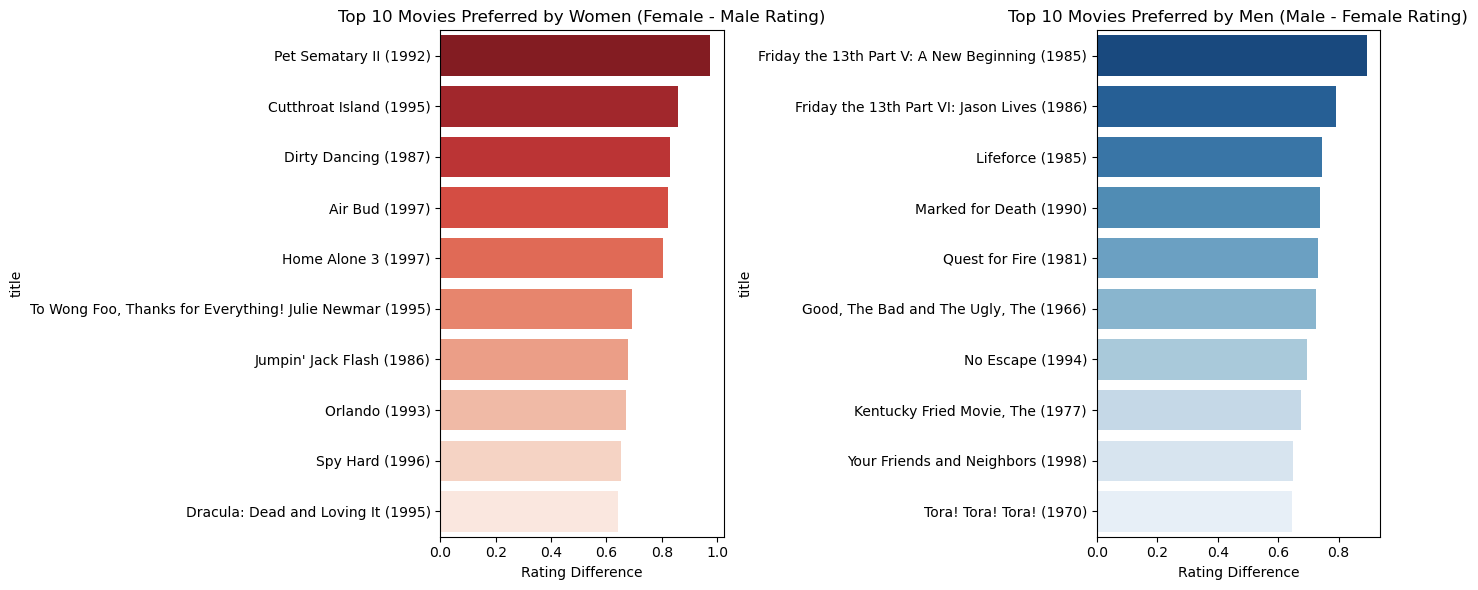

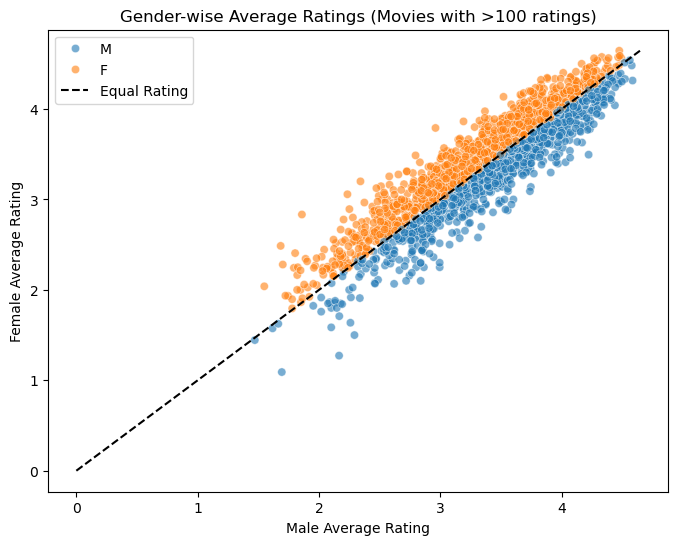

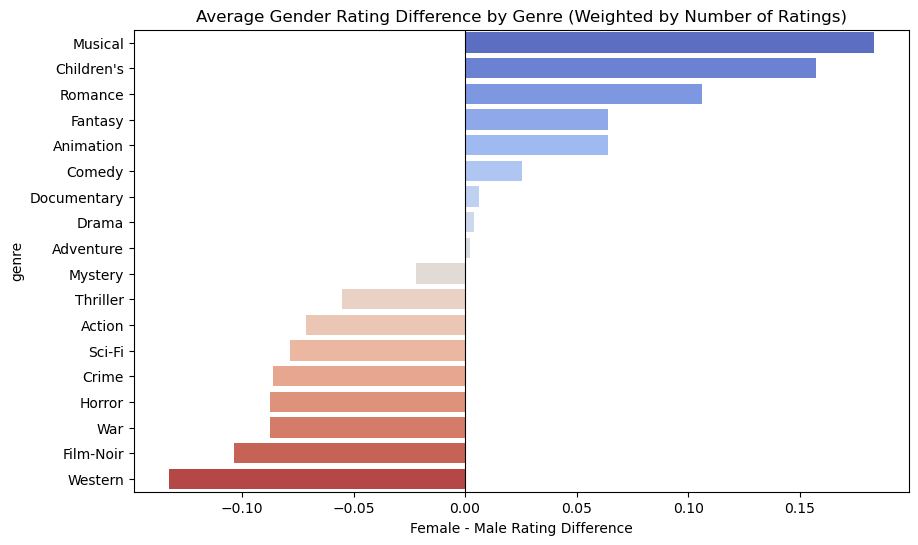

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 重命名列以免误解
result.rename(columns={'rating': 'rating_count'}, inplace=True)

# 计算男女评分差异的绝对值与方向
result['diff'] = result['female_rating'] - result['male_rating']
result['abs_diff'] = result['diff'].abs()

# 找出差异最大的电影（男女各偏向的前10部）
top_female_biased = result[result['more'] == 'F'].nlargest(10, 'diff')
top_male_biased   = result[result['more'] == 'M'].nlargest(10, 'abs_diff')  # 注意 male_biased 时 diff 为负

# 可视化1：男女评分差异最大的电影（柱状图）
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 女性偏好 Top10
sns.barplot(data=top_female_biased, y='title', x='diff', palette='Reds_r', ax=axes[0])
axes[0].set_title('Top 10 Movies Preferred by Women (Female - Male Rating)')
axes[0].set_xlabel('Rating Difference')

# 男性偏好 Top10（取绝对值后反向显示为正，但标题说明是男性高于女性）
top_male_biased_plot = top_male_biased.copy()
top_male_biased_plot['male_pref'] = -top_male_biased_plot['diff']  # 转为正值表示男性领先幅度
sns.barplot(data=top_male_biased_plot, y='title', x='male_pref', palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 10 Movies Preferred by Men (Male - Female Rating)')
axes[1].set_xlabel('Rating Difference')

plt.tight_layout()
plt.show()

# 可视化2：散点图展示全部电影的男女评分分布
plt.figure(figsize=(8, 6))
sns.scatterplot(data=result, x='male_rating', y='female_rating', hue='more', alpha=0.6)
# 添加对角线 y=x
max_val = max(result['male_rating'].max(), result['female_rating'].max())
plt.plot([0, max_val], [0, max_val], 'k--', label='Equal Rating')
plt.xlabel('Male Average Rating')
plt.ylabel('Female Average Rating')
plt.title('Gender-wise Average Ratings (Movies with >100 ratings)')
plt.legend()
plt.show()

# 可视化3：按类型聚合看男女评分差异
# 由于一部电影可能属于多个类型（以'|'分隔），我们需要展开类型
genre_list = []
for _, row in result.iterrows():
    for g in row['genres'].split('|'):
        genre_list.append({
            'genre': g,
            'female_rating': row['female_rating'],
            'male_rating': row['male_rating'],
            'diff': row['diff'],
            'rating_count': row['rating_count']
        })
genre_df = pd.DataFrame(genre_list)

# 计算每个类型的平均差异（加权评分次数可以减少小众电影的影响）
genre_stats = genre_df.groupby('genre').apply(
    lambda x: pd.Series({
        'avg_diff': np.average(x['diff'], weights=x['rating_count']),
        'movie_count': len(x)
    })
).reset_index().sort_values('avg_diff', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=genre_stats, y='genre', x='avg_diff', palette='coolwarm')
plt.title('Average Gender Rating Difference by Genre (Weighted by Number of Ratings)')
plt.xlabel('Female - Male Rating Difference')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

## 任务二、用户对电影的打分预测

设计合理的模型及评测方案，给出分析结果。可以用AI辅助。

建议分为封闭测试（对输入数据恢复的loss）和开放测试（分出10%的打分数据测试集，计算loss）


In [53]:
# todo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split, cross_validate

# ======================
# 1. 数据加载与初步查看
# ======================
# 假设数据已读取为 DataFrames: movies, users, ratings
# 此处模拟已加载完成
# ratings 列：['user_id', 'movie_id', 'rating', 'timestamp']
# 注意：Surprise 要求列顺序为 user, item, rating

# 查看基本信息
print("Ratings shape:", ratings.shape)
print("Users count:", ratings['user_id'].nunique())
print("Movies count:", ratings['movie_id'].nunique())
print("Sparsity: {:.2f}%".format(
    100 * (1 - len(ratings) / (ratings['user_id'].nunique() * ratings['movie_id'].nunique()))
))

# 评分分布
plt.figure(figsize=(6,4))
sns.countplot(data=ratings, x='rating')
plt.title('Distribution of Ratings')
plt.show()

# ======================
# 2. 构建 Surprise 数据集
# ======================
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['user_id', 'movie_id', 'rating']], reader)

# 划分训练集（90%）与测试集（10%）
trainset, testset = train_test_split(data, test_size=0.1, random_state=42)

# ======================
# 3. 模型定义与训练
# ======================
# 使用 SVD（FunkSVD），参数经过简单调优
model = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)

# 训练模型
model.fit(trainset)

# ======================
# 4. 封闭测试（在训练集上评估）
# ======================
# 注意：trainset 是 Surprise 的内部格式，需转换为原始评分列表进行预测
train_predictions = model.test(trainset.build_testset())
train_rmse = accuracy.rmse(train_predictions, verbose=True)
train_mae = accuracy.mae(train_predictions, verbose=True)

# ======================
# 5. 开放测试（在测试集上评估）
# ======================
test_predictions = model.test(testset)
test_rmse = accuracy.rmse(test_predictions, verbose=True)
test_mae = accuracy.mae(test_predictions, verbose=True)

# ======================
# 6. 结果汇总与对比
# ======================
results = pd.DataFrame({
    'Metric': ['RMSE', 'MAE'],
    'Closed (Train)': [train_rmse, train_mae],
    'Open (Test)': [test_rmse, test_mae]
})
print("\n=== 模型评测结果 ===")
print(results)

# ======================
# 7. 误差分布可视化
# ======================
test_errors = [pred.est - pred.r_ui for pred in test_predictions]
plt.figure(figsize=(8,5))
sns.histplot(test_errors, bins=30, kde=True)
plt.xlabel('Prediction Error (Predicted - Actual)')
plt.title('Distribution of Prediction Errors on Test Set')
plt.axvline(0, color='red', linestyle='--')
plt.show()

# ======================
# 8. 交叉验证（更稳健的评估）
# ======================
cv_results = cross_validate(model, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)
print("\n5-Fold CV Mean RMSE: {:.4f}".format(cv_results['test_rmse'].mean()))
print("5-Fold CV Mean MAE : {:.4f}".format(cv_results['test_mae'].mean()))

ModuleNotFoundError: No module named 'surprise'

FunkSVD（也称常规 SVD 或 LFM）是 Simon Funk 在 Netflix Prize 期间提出的矩阵分解方法，核心思想是将用户-物品评分矩阵分解为两个低维矩阵的乘积，从而预测缺失评分。

### 一、核心假设

- 用户的偏好可以用 **k 个潜在因子**（隐特征）表示，如“喜欢动作片程度”“喜欢喜剧程度”等。
- 电影的属性同样可用 **k 个潜在因子**表示。
- 用户对电影的评分 = 用户隐向量与电影隐向量的内积（点乘）。

### 二、数学表达式

预测用户 $u$ 对电影 $i$ 的评分：

$$
\hat{r}_{ui} = \mu + b_u + b_i + q_i^T p_u
$$

| 符号 | 含义 |
|------|------|
| $\mu$ | 全局平均评分 |
| $b_u$ | 用户偏置（某用户打分习惯偏高/偏低） |
| $b_i$ | 物品偏置（某电影本身质量偏高/偏低） |
| $p_u$ | 用户 $u$ 的隐向量（长度 $k$） |
| $q_i$ | 电影 $i$ 的隐向量（长度 $k$） |
| $q_i^T p_u$ | 隐向量点积，捕捉用户与电影的交互匹配度 |

### 三、学习过程

通过 **随机梯度下降（SGD）** 最小化带正则项的平方误差：

$$
\min_{p, q, b} \sum_{(u,i)\in \text{训练集}} (r_{ui} - \hat{r}_{ui})^2 + \lambda (\|p_u\|^2 + \|q_i\|^2 + b_u^2 + b_i^2)
$$

每一步更新规则（对每个已知评分）：

- 误差：$e_{ui} = r_{ui} - \hat{r}_{ui}$
- 更新偏置：$b_u \leftarrow b_u + \gamma (e_{ui} - \lambda b_u)$
- 更新隐向量：$p_u \leftarrow p_u + \gamma (e_{ui} \cdot q_i - \lambda p_u)$，$q_i$ 同理

其中 $\gamma$ 为学习率，$\lambda$ 为正则化系数。

### 四、为什么有效

- **降维**：将稀疏的 $m \times n$ 评分矩阵压缩为两个 $m \times k$ 和 $n \times k$ 的小矩阵（$k \approx 50\sim200$）。
- **泛化**：即使用户只评价过少量电影，通过隐向量也能推断他对相似电影的偏好。
- **可解释性**：隐向量各维度常对应可理解的语义（如“阳刚-阴柔”“严肃-轻松”），但需后验分析。

### 五、与你代码的对应关系

- `Surprise` 库的 `SVD` 类即实现了 FunkSVD（含偏置项）。
- `n_factors=100` 设置隐向量维度 $k=100$。
- `lr_all=0.005` 为 SGD 学习率 $\gamma$。
- `reg_all=0.02` 为正则化系数 $\lambda$。